In [3]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from multiprocessing import Pool, cpu_count
import os
from scipy.optimize import curve_fit

# Output directory
OUTPUT_DIR = 'MW_torsion_curves/Paper_family_unconstrained'
os.makedirs(OUTPUT_DIR, exist_ok=True)

#=======================
# Deshpande et al.'s paper family: y^2 = x^3 - D^2 x, D integer.
#=======================

NUM_PRIMES = 1000
PRIMES = list(primes_first_n(NUM_PRIMES))

def elliptic_curve_from_phi_sage(phi):
    from sage.all import EllipticCurve
    return EllipticCurve([0, 0, 0, -phi**2, 0])

def get_isogeny_class(label):
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]

def process_phi(phi):
    try:
        E = elliptic_curve_from_phi_sage(phi)
        E_min = E.minimal_model()
        label = E_min.label()
        iso = get_isogeny_class(label)
        N = E_min.conductor()
        rk = E_min.rank()
        ap_list = [int(E_min.ap(p)) for p in PRIMES]
        return (phi, int(N), iso, rk, ap_list)
    except:
        return None

def power_law(x, A, alpha):
    return A / (x**alpha)

# ============================================================================
# SCAN AND PROCESS
# ============================================================================

phi_max = 500
phis = list(range(1, phi_max + 1))

print(f"Processing {len(phis)} integer phis...")
with Pool(processes=cpu_count()) as pool:
    results = list(tqdm(pool.imap(process_phi, phis), total=len(phis)))

# Track isogeny class multiplicities
iso_to_phis = {}
iso_to_count = {}
phi_to_iso = {}
for phi, result in zip(phis, results):
    if result is not None:
        _, _, iso, _, _ = result
        phi_to_iso[phi] = iso
        if iso not in iso_to_phis:
            iso_to_phis[iso] = []
        iso_to_phis[iso].append(phi)
        iso_to_count[iso] = iso_to_count.get(iso, 0) + 1
    else:
        phi_to_iso[phi] = None

# Compute multiplicity for each phi
multiplicities = [iso_to_count[phi_to_iso[phi]] if phi_to_iso[phi] is not None else 0 for phi in phis]

# Filter to unique isogeny classes
Ns, seen_iso_classes, phi_reps, ranks, ap_lists = [], [], [], [], []
for result in results:
    if result is not None:
        phi, N, iso, rk, ap_list = result
        if iso not in seen_iso_classes:
            Ns.append(N)
            seen_iso_classes.append(iso)
            phi_reps.append(phi)
            ranks.append(rk)
            ap_lists.append(ap_list)

print(f"Found {len(phi_reps)} distinct isogeny classes")

# ============================================================================
# SAVE RESULTS
# ============================================================================

print("Saving data...")
scan_data = {
    'phi_reps': phi_reps,
    'conductors': Ns,
    'isogeny_classes': seen_iso_classes,
    'ranks': ranks,
    'ap_lists': ap_lists,
    'primes': PRIMES,
    'all_phis': phis,
    'multiplicities': multiplicities,
    'phi_to_iso': phi_to_iso,
    'iso_to_count': iso_to_count,
    'iso_to_phis': iso_to_phis,
    'total_phis_generated': len(phis),
    'total_found': len(phi_reps),
    'phi_max': phi_max
}
save(scan_data, f'{OUTPUT_DIR}/phi_max_{phi_max}_scan_data.sobj')

# ============================================================================
# PLOTTING
# ============================================================================

print("Creating plots...")

# Multiplicity vs phi
plt.figure(figsize=(14, 7))
scatter = plt.scatter(phis, multiplicities, c=multiplicities, cmap='plasma',
                      alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
plt.colorbar(scatter, label='Multiplicity')
plt.xlabel(r'$\phi$', fontsize=14)
plt.ylabel('Multiplicity (# phis → same isogeny class)', fontsize=14)
plt.title(fr'Isogeny class multiplicity vs $\phi$ ($\phi \in [1, {phi_max}]$)', fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Multiplicity = 1')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phi_max_{phi_max}_multiplicity_vs_phi.png', dpi=150)
plt.close()

# Phi distribution (density histogram)
plt.figure(figsize=(12, 6))
plt.hist(phi_reps, bins=50, density=False, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel(r'$\phi$', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title(fr'Distribution of $\phi$ representatives ($\phi \in [1, {phi_max}]$, {len(phi_reps)} unique)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phi_max_{phi_max}_phi_distribution.png', dpi=150)
plt.close()

# Conductor vs phi
plt.figure(figsize=(12, 7))
plt.scatter(phi_reps, Ns, c=Ns, cmap='viridis', alpha=0.6, s=25, edgecolors='black', linewidth=0.3)
plt.colorbar(label='Conductor $N$')
plt.xlabel(r'$\phi$', fontsize=14)
plt.ylabel(r'Conductor $N$', fontsize=14)
plt.title(fr'Conductor vs $\phi$ ($\phi \in [1, {phi_max}]$)', fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phi_max_{phi_max}_conductor_vs_phi.png', dpi=150)
plt.close()

# Conductor distribution with power law fit
plt.figure(figsize=(14, 6))
counts_N, bins_N, _ = plt.hist(Ns, bins=100, density=True, alpha=0.6, label='Data')
bin_centers_N = (bins_N[:-1] + bins_N[1:]) / 2
mask_N = counts_N > 0

try:
    popt_N, _ = curve_fit(power_law, bin_centers_N[mask_N], counts_N[mask_N], p0=[1e6, 1.5], maxfev=10000)
    A_fit, alpha_fit = popt_N
    x_fit_N = np.linspace(min(Ns), max(Ns), 1000)
    plt.plot(x_fit_N, power_law(x_fit_N, A_fit, alpha_fit), 'r-', linewidth=2,
             label=f'Power law: α={alpha_fit:.3f}')
except Exception as e:
    print(f"Power law fit failed: {e}")

plt.xlabel(r"Conductor $N$", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(fr"Conductor distribution, $\phi \in [1, {phi_max}]$", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phi_max_{phi_max}_conductor_distribution.png', dpi=150)
plt.close()

# Isogeny class multiplicity histogram
mult_counts = {}
for m in [len(phis_list) for phis_list in iso_to_phis.values()]:
    mult_counts[m] = mult_counts.get(m, 0) + 1

plt.figure(figsize=(12, 6))
mult_values = sorted(mult_counts.keys())
mult_freqs = [mult_counts[m] for m in mult_values]
plt.bar(mult_values, mult_freqs, color='teal', edgecolor='black', alpha=0.7)
plt.xlabel('Multiplicity', fontsize=14)
plt.ylabel('Number of isogeny classes', fontsize=14)
plt.title(fr'Isogeny class multiplicities ($\phi \in [1, {phi_max}]$)', fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phi_max_{phi_max}_multiplicity_histogram.png', dpi=150)
plt.close()

# ============================================================================
# FROBENIUS TRACES BY RANK
# ============================================================================

print("Computing average Frobenius traces by rank...")
rk0_traces = [ap_lists[i] for i in range(len(ranks)) if ranks[i] == 0]
rk1_traces = [ap_lists[i] for i in range(len(ranks)) if ranks[i] == 1]

rk0_traces = np.array(rk0_traces) if rk0_traces else None
rk1_traces = np.array(rk1_traces) if rk1_traces else None

rk0_avg = np.mean(rk0_traces, axis=0) if rk0_traces is not None else None
rk1_avg = np.mean(rk1_traces, axis=0) if rk1_traces is not None else None

if rk0_traces is not None:
    print(f"Rank 0: {len(rk0_traces)} isogeny classes")
if rk1_traces is not None:
    print(f"Rank 1: {len(rk1_traces)} isogeny classes")

save({'rank_0_average': rk0_avg.tolist() if rk0_avg is not None else None,
      'rank_1_average': rk1_avg.tolist() if rk1_avg is not None else None,
      'rank_0_count': len(rk0_traces) if rk0_traces is not None else 0,
      'rank_1_count': len(rk1_traces) if rk1_traces is not None else 0},
     f'{OUTPUT_DIR}/phi_max_{phi_max}_average_traces.sobj')

# Frobenius trace plot
if rk0_avg is not None or rk1_avg is not None:
    plt.figure(figsize=(14, 7))
    if rk0_avg is not None:
        plt.scatter(range(NUM_PRIMES), rk0_avg, 
                    label=f"Rank 0 (n={len(rk0_traces)})", alpha=0.6, s=15)
    if rk1_avg is not None:
        plt.scatter(range(NUM_PRIMES), rk1_avg, 
                    label=f"Rank 1 (n={len(rk1_traces)})", alpha=0.6, s=15)

    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    plt.legend(fontsize=12)
    plt.xlabel(r"Prime index $i$", fontsize=12)
    plt.ylabel(r"Average Frobenius trace $a_{p_i}$", fontsize=12)
    plt.title(fr"Average Frobenius traces vs prime index, $\phi \in [1, {phi_max}]$", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/phi_max_{phi_max}_frobenius_traces.png', dpi=150)
    plt.close()

print("Done!")

Processing 500 integer phis...


100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [00:03<00:00, 143.87it/s]


Found 87 distinct isogeny classes
Saving data...
Creating plots...
Computing average Frobenius traces by rank...
Rank 0: 36 isogeny classes
Rank 1: 46 isogeny classes
Done!


In [28]:
phi_data = load('MW_torsion_curves/Paper_family/phi_max_500_scan_data.sobj')
phi_reps = phi_data['phi_reps']
cs = phi_data['conductors']

In [30]:
phis_up = [x for x in phi_reps if not x % 2 == 0]

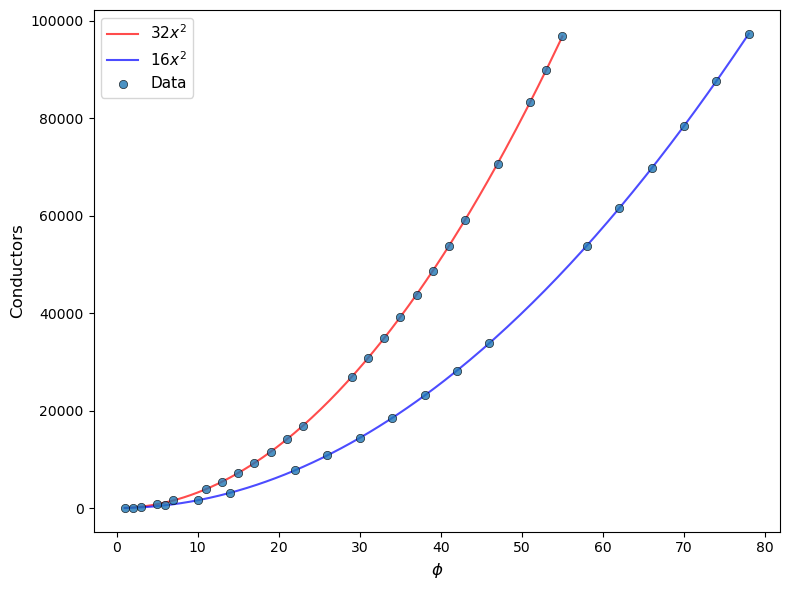

In [34]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: 32*x**2
g = lambda x: 16*x**2

# Plot
x_fit_f = np.linspace(min(phi_reps), max(phis_up), 200)
x_fit_g = np.linspace(min(phi_reps), max(phi_reps), 200)

plt.figure(figsize=(8, 6))
plt.plot(x_fit_f, f(x_fit_f), 'r-', label=r'$32x^2$', linewidth=1.5, alpha=0.7)
plt.plot(x_fit_g, g(x_fit_g), 'b-', label=r'$16x^2$', linewidth=1.5, alpha=0.7)
plt.scatter(phi_reps, cs, label='Data', alpha=0.8, edgecolors='k', linewidths=0.5, zorder=5)

plt.xlabel(r'$\phi$', fontsize=12)
plt.ylabel('Conductors', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [35]:
phi_reps

[1,
 2,
 3,
 5,
 6,
 7,
 10,
 11,
 13,
 14,
 15,
 17,
 19,
 21,
 22,
 23,
 26,
 29,
 30,
 31,
 33,
 34,
 35,
 37,
 38,
 39,
 41,
 42,
 43,
 46,
 47,
 51,
 53,
 55,
 58,
 62,
 66,
 70,
 74,
 78]

In [36]:
non_squarefree = [x for x in phi_reps if not ZZ(x).is_squarefree()]
if non_squarefree:
    print(f'Not squarefree: {non_squarefree}')
else:
    print('All phi reps are squarefree')

All phi reps are squarefree


In [37]:
len(phi_reps)

40

In [40]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from multiprocessing import Pool, cpu_count
import os
from scipy.optimize import curve_fit

# Output directory
OUTPUT_DIR = 'MW_torsion_curves/Paper_family_unconstrained'
os.makedirs(OUTPUT_DIR, exist_ok=True)

#=======================
# Deshpande et al.'s paper family: y^2 = x^3 - D^2 x, D integer.
#=======================

NUM_PRIMES = 1000
PRIMES = list(primes_first_n(NUM_PRIMES))

def elliptic_curve_from_phi_sage(phi):
    from sage.all import EllipticCurve
    return EllipticCurve([0, 0, 0, -phi**2, 0])

def get_isogeny_class(label):
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]

def process_phi(phi):
    try:
        E = elliptic_curve_from_phi_sage(phi)
        E_min = E.minimal_model()
        label = E_min.label()
        iso = get_isogeny_class(label)
        N = E_min.conductor()
        rk = E_min.rank()
        ap_list = [int(E_min.ap(p)) for p in PRIMES]
        return (phi, int(N), iso, rk, ap_list)
    except:
        return None

def power_law(x, A, alpha):
    return A / (x**alpha)

# ============================================================================
# SCAN AND PROCESS
# ============================================================================

phi_max = 1000
phis = list(range(1, phi_max + 1))

print(f"Processing {len(phis)} integer phis...")
with Pool(processes=cpu_count()) as pool:
    results = list(tqdm(pool.imap(process_phi, phis), total=len(phis)))

# Track isogeny class multiplicities
iso_to_phis = {}
iso_to_count = {}
phi_to_iso = {}
for phi, result in zip(phis, results):
    if result is not None:
        _, _, iso, _, _ = result
        phi_to_iso[phi] = iso
        if iso not in iso_to_phis:
            iso_to_phis[iso] = []
        iso_to_phis[iso].append(phi)
        iso_to_count[iso] = iso_to_count.get(iso, 0) + 1
    else:
        phi_to_iso[phi] = None

# Compute multiplicity for each phi
multiplicities = [iso_to_count[phi_to_iso[phi]] if phi_to_iso[phi] is not None else 0 for phi in phis]

# Filter to unique isogeny classes
Ns, seen_iso_classes, phi_reps, ranks, ap_lists = [], [], [], [], []
for result in results:
    if result is not None:
        phi, N, iso, rk, ap_list = result
        if iso not in seen_iso_classes:
            Ns.append(N)
            seen_iso_classes.append(iso)
            phi_reps.append(phi)
            ranks.append(rk)
            ap_lists.append(ap_list)

print(f"Found {len(phi_reps)} distinct isogeny classes")

# ============================================================================
# SAVE RESULTS
# ============================================================================

print("Saving data...")
scan_data = {
    'phi_reps': phi_reps,
    'conductors': Ns,
    'isogeny_classes': seen_iso_classes,
    'ranks': ranks,
    'ap_lists': ap_lists,
    'primes': PRIMES,
    'all_phis': phis,
    'multiplicities': multiplicities,
    'phi_to_iso': phi_to_iso,
    'iso_to_count': iso_to_count,
    'iso_to_phis': iso_to_phis,
    'total_phis_generated': len(phis),
    'total_found': len(phi_reps),
    'phi_max': phi_max
}
save(scan_data, f'{OUTPUT_DIR}/phi_max_{phi_max}_scan_data.sobj')

# ============================================================================
# PLOTTING
# ============================================================================

print("Creating plots...")

# Multiplicity vs phi
plt.figure(figsize=(14, 7))
scatter = plt.scatter(phis, multiplicities, c=multiplicities, cmap='plasma',
                      alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
plt.colorbar(scatter, label='Multiplicity')
plt.xlabel(r'$\phi$', fontsize=14)
plt.ylabel('Multiplicity (# phis → same isogeny class)', fontsize=14)
plt.title(fr'Isogeny class multiplicity vs $\phi$ ($\phi \in [1, {phi_max}]$)', fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Multiplicity = 1')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phi_max_{phi_max}_multiplicity_vs_phi.png', dpi=150)
plt.close()

# Conductor vs phi
plt.figure(figsize=(12, 7))
plt.scatter(phi_reps, Ns, c=Ns, cmap='viridis', alpha=0.6, s=25, edgecolors='black', linewidth=0.3)
plt.colorbar(label='Conductor $N$')
plt.xlabel(r'$\phi$', fontsize=14)
plt.ylabel(r'Conductor $N$', fontsize=14)
plt.title(fr'Conductor vs $\phi$ ($\phi \in [1, {phi_max}]$)', fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phi_max_{phi_max}_conductor_vs_phi.png', dpi=150)
plt.close()

# Conductor distribution with power law fit
plt.figure(figsize=(14, 6))
counts_N, bins_N, _ = plt.hist(Ns, bins=100, density=True, alpha=0.6, label='Data')
bin_centers_N = (bins_N[:-1] + bins_N[1:]) / 2
mask_N = counts_N > 0

try:
    popt_N, _ = curve_fit(power_law, bin_centers_N[mask_N], counts_N[mask_N], p0=[1e6, 1.5], maxfev=10000)
    A_fit, alpha_fit = popt_N
    x_fit_N = np.linspace(min(Ns), max(Ns), 1000)
    plt.plot(x_fit_N, power_law(x_fit_N, A_fit, alpha_fit), 'r-', linewidth=2,
             label=f'Power law: α={alpha_fit:.3f}')
except Exception as e:
    print(f"Power law fit failed: {e}")

plt.xlabel(r"Conductor $N$", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(fr"Conductor distribution, $\phi \in [1, {phi_max}]$", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phi_max_{phi_max}_conductor_distribution.png', dpi=150)
plt.close()

# Isogeny class multiplicity histogram
mult_counts = {}
for m in [len(phis_list) for phis_list in iso_to_phis.values()]:
    mult_counts[m] = mult_counts.get(m, 0) + 1

plt.figure(figsize=(12, 6))
mult_values = sorted(mult_counts.keys())
mult_freqs = [mult_counts[m] for m in mult_values]
plt.bar(mult_values, mult_freqs, color='teal', edgecolor='black', alpha=0.7)
plt.xlabel('Multiplicity', fontsize=14)
plt.ylabel('Number of isogeny classes', fontsize=14)
plt.title(fr'Isogeny class multiplicities ($\phi \in [1, {phi_max}]$)', fontsize=16)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phi_max_{phi_max}_multiplicity_histogram.png', dpi=150)
plt.close()

# ============================================================================
# FROBENIUS TRACES BY RANK
# ============================================================================

print("Computing average Frobenius traces by rank...")
rk0_traces = [ap_lists[i] for i in range(len(ranks)) if ranks[i] == 0]
rk1_traces = [ap_lists[i] for i in range(len(ranks)) if ranks[i] == 1]

rk0_traces = np.array(rk0_traces) if rk0_traces else None
rk1_traces = np.array(rk1_traces) if rk1_traces else None

rk0_avg = np.mean(rk0_traces, axis=0) if rk0_traces is not None else None
rk1_avg = np.mean(rk1_traces, axis=0) if rk1_traces is not None else None

if rk0_traces is not None:
    print(f"Rank 0: {len(rk0_traces)} isogeny classes")
if rk1_traces is not None:
    print(f"Rank 1: {len(rk1_traces)} isogeny classes")

save({'rank_0_average': rk0_avg.tolist() if rk0_avg is not None else None,
      'rank_1_average': rk1_avg.tolist() if rk1_avg is not None else None,
      'rank_0_count': len(rk0_traces) if rk0_traces is not None else 0,
      'rank_1_count': len(rk1_traces) if rk1_traces is not None else 0},
     f'{OUTPUT_DIR}/phi_max_{phi_max}_average_traces.sobj')

# Frobenius trace plot
if rk0_avg is not None or rk1_avg is not None:
    plt.figure(figsize=(14, 7))
    if rk0_avg is not None:
        plt.scatter(range(NUM_PRIMES), rk0_avg, 
                    label=f"Rank 0 (n={len(rk0_traces)})", alpha=0.6, s=15)
    if rk1_avg is not None:
        plt.scatter(range(NUM_PRIMES), rk1_avg, 
                    label=f"Rank 1 (n={len(rk1_traces)})", alpha=0.6, s=15)

    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    plt.legend(fontsize=12)
    plt.xlabel(r"Prime index $i$", fontsize=12)
    plt.ylabel(r"Average Frobenius trace $a_{p_i}$", fontsize=12)
    plt.title(fr"Average Frobenius traces vs prime index, $\phi \in [1, {phi_max}]$", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/phi_max_{phi_max}_frobenius_traces.png', dpi=150)
    plt.close()

print("Done!")

Processing 1000 integer phis...


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:09<00:00, 109.55it/s]


Found 87 distinct isogeny classes
Saving data...
Creating plots...
Computing average Frobenius traces by rank...
Rank 0: 36 isogeny classes
Rank 1: 46 isogeny classes
Done!
